# Modelling the Economics and Risk of a USGC → Rotterdam Crude Oil Trade


## Objective

This project investigates the profitability of a crude oil trade, when bought in the US Gulf Coast, transported to Rotterdam, and sold into the European market with the support of historical data. 

# Contents

## 1. Data Import and Preparation

## 2. Trade Economics and Break-even Spread

### 2.1 Key Indicators
### 2.2 Break-even Spread
### 2.3 Price Sensitivity Graph
### 2.4 Freight Sensitivity Graph
### 2.5 Voyage-duration Sensitivity Graph

## 3. Historical Profitability


### 3.1 Historical WTI and Brent Spot Prices
### 3.2 Historical WTI and Brent Spread
### 3.3 Indicative Profitability Graph
### 3.4 Summary Statistics

## 4. Voyage-Horizon Spread Risk


### 4.1 18-Day Spread Change - Mean and Volatility
### 4.2 Distribution of 18-Day Spread Changes
### 4.3 Skewness and Excess Kurtosis

## 5. Monte Carlo Simulation

### 5.1 Historical Bootstrap Model
### 5.2 Simulated Cargo Profit
### 5.3 Probability of Loss
### 5.4 VaR and CVaR
### 5.5 Histogram Illustration of the Simulated Cargo Profits

## 6. Mean-Reversion Analysis

### 6.1 18-Day Spread Change vs Starting Spread
### 6.2 Correlation Analysis
### 6.3 Regression Analysis
### 6.4 Augmented Dickey-Fuller Test

## 7. Freight Sensitivity

### 7.1 Freight Sensitivity Table
### 7.2 Impact on Historical Profitability
### 7.3 Zero-Profit Freight Threshold
### 7.4 Impact on Average Cargo Profit


## 8. Limitations

## 9. Conclusion

# Project

## 1. Data Import and Preparation


We established the initial parameters that act as the base to the project.

In [47]:
cargo_size = 600000          # barrels
us_price = 70.00             # $/barrel
europe_price = 75.00         # $/barrel
freight_per_bbl = 3.50       # $/barrel
trade_duration = 25          # days
annual_capital_cost = 0.05   # 5%
other_costs_per_bbl = 0.20   # insurance + port costs

## 2. Trade Economics and Break-even Spread


### 2.1 Key Indicators

In [ ]:
# Purchase cost
purchase_cost = cargo_size * us_price

# Freight cost
freight_cost = cargo_size * freight_per_bbl

# Cost of capital
capital_cost = purchase_cost * annual_capital_cost * (trade_duration / 365)

# Insurance + port costs
other_costs = cargo_size * other_costs_per_bbl

# Total revenue
revenue = cargo_size * europe_price

# Total cost
total_cost = purchase_cost + freight_cost + capital_cost + other_costs

# Profit
profit = revenue - total_cost

# Profit per barrpel 
profit_per_bbl = profit / cargo_size

# Price spread
spread = europe_price - us_price

### 2.2 Break-even Spread

In [49]:
# Break-even spread
capital_cost_per_bbl = capital_cost / cargo_size
break_even_spread = freight_per_bbl + other_costs_per_bbl + capital_cost_per_bbl

### 2.3 Price Spread Sensitivity Graph

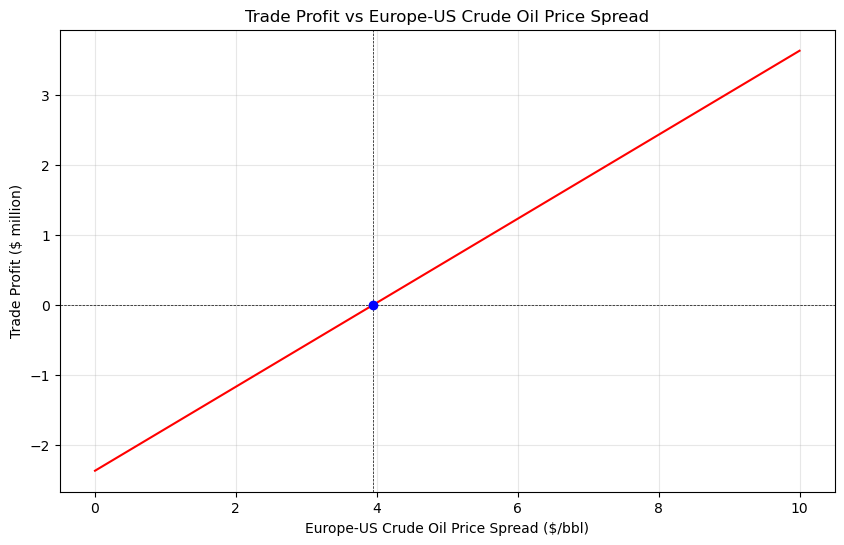

In [50]:
# Price spread sensitivity graph
import numpy as np
import matplotlib.pyplot as plt

spreads = np.linspace(0,10,101)
profit_per_bbl = spreads - break_even_spread

profits = cargo_size * profit_per_bbl

plt.figure(figsize = (10,6))
plt.plot(spreads, profits/1000000, color = 'red')
plt.axhline(0, linestyle = '--', linewidth = 0.5, color = 'black')
plt.axvline(break_even_spread, linestyle = '--', linewidth = 0.5, color = 'black')
plt.plot(break_even_spread,0,'bo')
plt.xlabel('Europe-US Crude Oil Price Spread ($/bbl)')
plt.ylabel('Trade Profit ($ million)')
plt.title('Trade Profit vs Europe-US Crude Oil Price Spread')
plt.grid(True, alpha = 0.3)
plt.show()

### 2.4 Freight Sensitivity Graph

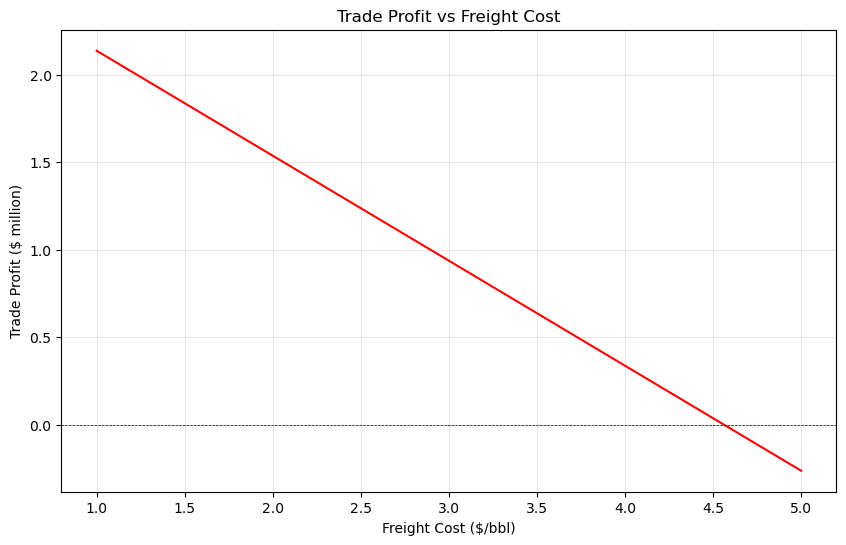

In [51]:
# Freight sensitivity graph
# Price spread constant at $5 per bbl

freight_range = np.linspace(1, 5, 101)

non_freight_costs = capital_cost_per_bbl + other_costs_per_bbl

freight_profit_per_bbl = spread - freight_range - non_freight_costs

freight_profit = cargo_size * freight_profit_per_bbl

plt.figure(figsize = (10,6))
plt.plot(freight_range, freight_profit/1000000, color = 'red')
plt.axhline(0, linestyle = '--', color = 'black', linewidth = 0.5)
plt.xlabel('Freight Cost ($/bbl)')
plt.ylabel('Trade Profit ($ million)')
plt.title('Trade Profit vs Freight Cost')
plt.grid(True, alpha = 0.3)
plt.show()

### 2.5 Voyage-duration Sensitivity Graph

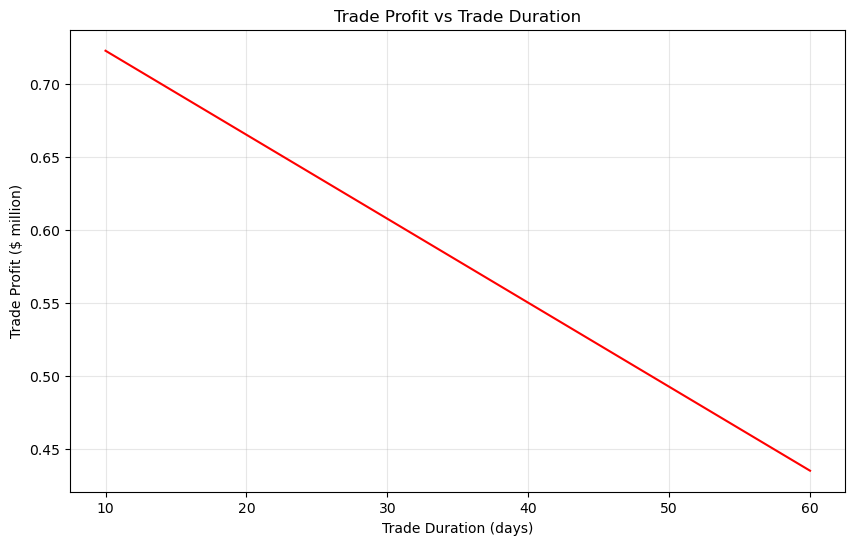

In [52]:
# Voyage duration sensitivity

durations = np.arange(10, 61)

capital_costs_duration = purchase_cost * annual_capital_cost * (durations / 365)

duration_profits = revenue - purchase_cost - freight_cost - other_costs - capital_costs_duration

plt.figure(figsize = (10,6))
plt.plot(durations, duration_profits/1000000, color = 'red')
plt.xlabel('Trade Duration (days)')
plt.ylabel('Trade Profit ($ million)')
plt.title('Trade Profit vs Trade Duration')
plt.grid(True, alpha = 0.3)
plt.show()

## 3. Historical Profitability

### 3.1 Historical WTI and Brent Spot Prices

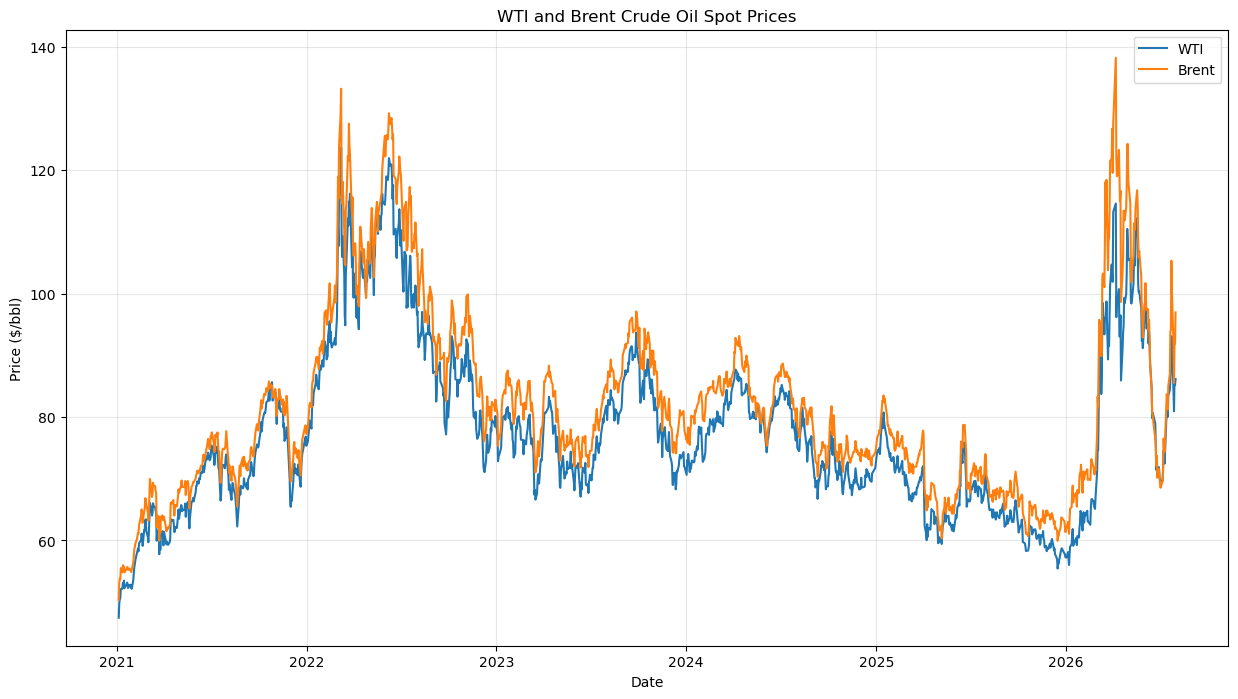

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr

start_date = "2021-01-01"
end_date = "2026-08-01"

oil = pdr.DataReader(["DCOILWTICO", "DCOILBRENTEU"], "fred", start_date, end_date)

oil.columns = ["WTI", "Brent"]

oil = oil.dropna()


plt.figure(figsize = (15,8))

plt.plot(oil.index, oil["WTI"], label = "WTI")
plt.plot(oil.index, oil["Brent"], label = "Brent")

plt.xlabel("Date")
plt.ylabel("Price ($/bbl)")
plt.title("WTI and Brent Crude Oil Spot Prices")

plt.legend(loc = "best")
plt.grid(True, alpha = 0.3)
plt.show()

### 3.2 Historical WTI and Brent Spread

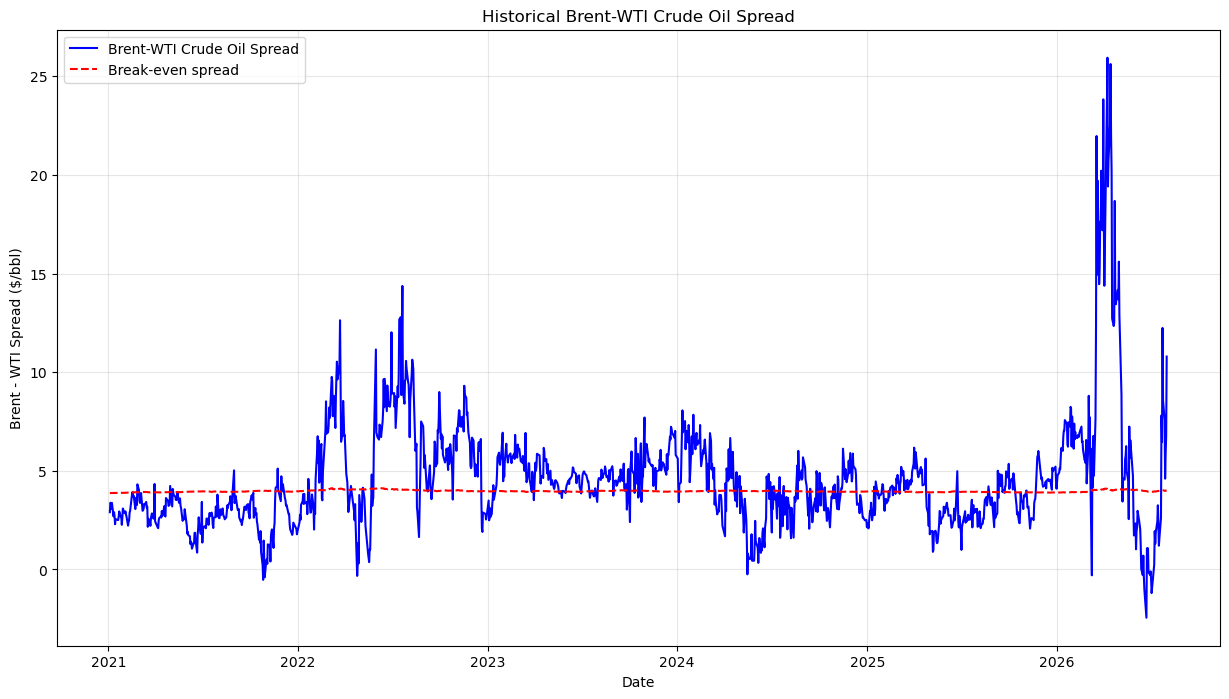

In [80]:
oil["Spread"] = oil["Brent"] - oil["WTI"]

#Break-even spread variance
oil["Capital Cost per bbl"] = oil["WTI"] *  annual_capital_cost * (trade_duration / 365)
oil["Break-even Spread"] = oil["Capital Cost per bbl"] + freight_per_bbl + other_costs_per_bbl 

plt.figure(figsize = (15,8))
plt.plot(oil.index, oil["Spread"], linestyle = '-', label = "Brent-WTI Crude Oil Spread", color = 'blue')
plt.plot(oil.index, oil["Break-even Spread"], linestyle = '--', label = "Break-even spread", color = 'red')
plt.axhline(0, linewidth = 0., color = 'black')
plt.xlabel('Date')
plt.ylabel('Brent - WTI Spread ($/bbl)')
plt.title('Historical Brent-WTI Crude Oil Spread')
plt.legend(loc = 'best')
plt.grid(True, alpha = 0.3)
plt.show()

### 3.3 Indicative Profitability Graph

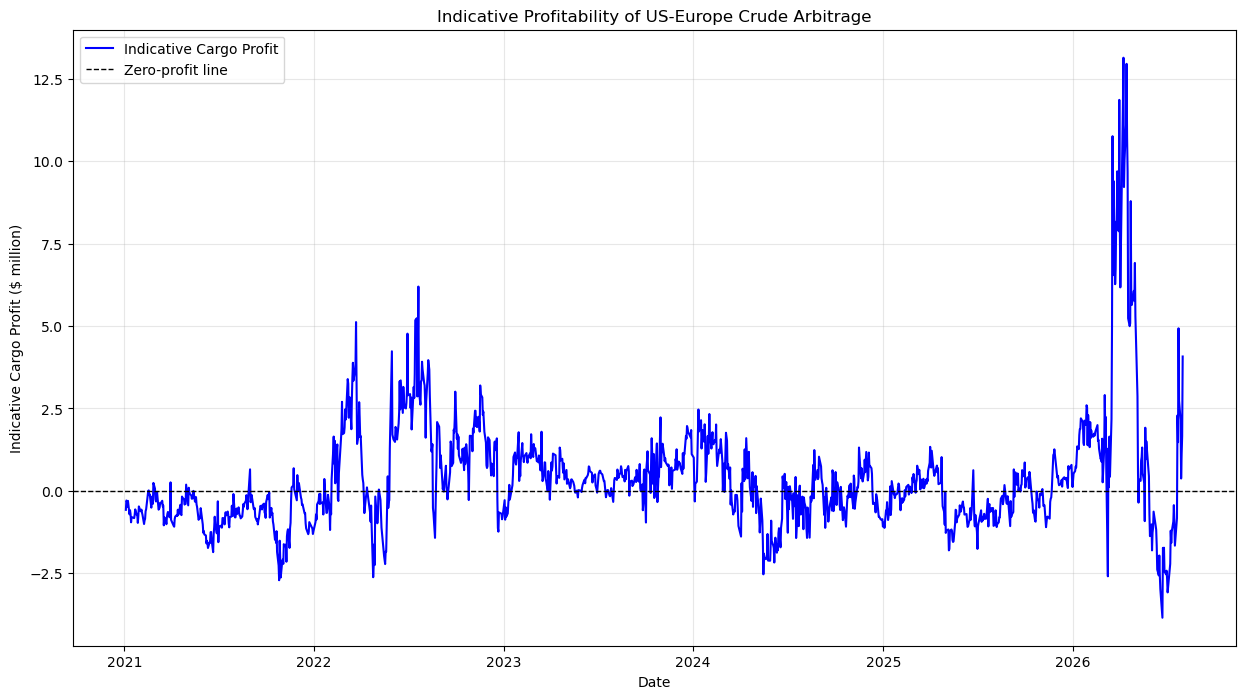

In [81]:
#Indicative profit per barrel 

oil["Indicative Profit per bbl"] = oil["Spread"] - oil["Break-even Spread"]
oil["Indicative Cargo Profit"] = oil["Indicative Profit per bbl"] * cargo_size

oil["Apparently Profitable"] = oil["Indicative Profit per bbl"] > 0

profitable_days = oil["Apparently Profitable"].sum()
total_days = len(oil)

percentage_profitable = (profitable_days/total_days) * 100 

plt.figure(figsize = (15,8))
plt.plot(oil.index, oil["Indicative Cargo Profit"]/1000000, linestyle = '-', color = 'blue', label = 'Indicative Cargo Profit')
plt.xlabel('Date')
plt.ylabel('Indicative Cargo Profit ($ million)')
plt.title('Indicative Profitability of US-Europe Crude Arbitrage')
plt.axhline(0, linestyle = '--', color = 'black', linewidth = 1.0, label = 'Zero-profit line')
plt.legend(loc = 'best')
plt.grid(True, alpha = 0.3)
plt.show()

### 3.4 Summary Statistics

In [82]:
summary_stats = {"Number of observations": len(oil),
                 "Average spread ($/bbl)": oil["Spread"].mean(),
                 "Median spread ($/bbl)": oil["Spread"].median(),
                 "Average break-even spread ($/bbl)": oil["Break-even Spread"].mean(),
                 "Average indicative profit ($/bbl)": oil["Indicative Profit per bbl"].mean(),
                 "Average indicative cargo profit ($m)": oil["Indicative Cargo Profit"].mean()/1000000,
                 "Maximum indicative cargo profit ($m)": oil["Indicative Cargo Profit"].max()/1000000,
                 "Minimum indicative cargo profit ($m)": oil["Indicative Cargo Profit"].min()/1000000,
                 "Apparently profitable days (%)": oil["Apparently Profitable"].mean() * 100}


for statistic, value in summary_stats.items():
    print(f"{statistic}: {value:.2f}")

Number of observations: 1367.00
Average spread ($/bbl): 4.57
Median spread ($/bbl): 4.10
Average break-even spread ($/bbl): 3.96
Average indicative profit ($/bbl): 0.61
Average indicative cargo profit ($m): 0.36
Maximum indicative cargo profit ($m): 13.15
Minimum indicative cargo profit ($m): -3.85
Apparently profitable days (%): 52.89


## 4. Voyage-Horizon Spread Risk

### 4.1 18-Day Spread Change - Mean and Volatility

The dates in the oil dataframe correspond to trading days NOT calendar days
Usually, there are 5 trading days in one week, not 7.

So for a 25 day trade duration, it only corresponds to 5/7 x 25 trading days which roughly is 18 trading days.

Therefore, we will consider how the spread changes over an 18 Day period in the oil dataframe.

In [83]:
oil["18 Day Spread Change"] = oil["Spread"] - oil["Spread"].shift(18)

mean_18d = oil["18 Day Spread Change"].mean()
std_18d = oil["18 Day Spread Change"].std()

print(f"Mean 18-day spread change: ${mean_18d:.3f}/bbl")
print(f"18-day spread volatility: ${std_18d:.3f}/bbl")

Mean 18-day spread change: $0.029/bbl
18-day spread volatility: $3.151/bbl


### 4.2 Distribution of 18-Day Spread Changes

Now we need to look at how the 18 day spread changes were distributed.

We can use a histogram to illustrate this, with the x-axis being 18 day spread changes and y-axis being frequency. 

Will provide information about what kinds of 18 day spread changes occurred more frequently and if there is a clear distribution e.g. a normal distribution.


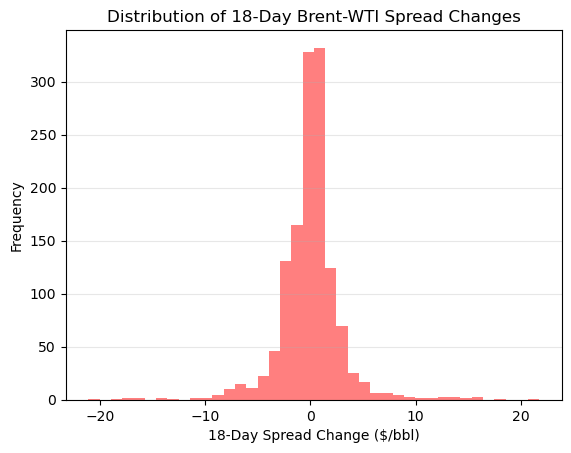

In [84]:
plt.hist(oil["18 Day Spread Change"].dropna(), bins=40, color = 'red', alpha = 0.5)

plt.xlabel("18-Day Spread Change ($/bbl)")
plt.ylabel("Frequency")
plt.title("Distribution of 18-Day Brent-WTI Spread Changes")
plt.grid(axis = "y", alpha = 0.3)

plt.show()

### 4.3 Skewness and Excess Kurtosis

From the plotted histogram, we can see that it is centered around $0 displaying sharp peaks around this, which we see also in normally distributed data

However, a normal distribution would likely be unsuitable to represent the data due to the tails seen on the histogram being longer than what is typically seen in normal distributions

To analyse the data numerically, we can consider the skewness and kurtosis of the data

Skewness refers to how asymmetric the data is; skewness = 0 would indicate the data is roughly symmetric; skewness > 0 would indicate a longer/heavier right hand tail and vice versa

Kurtosis is how heavy the tails are; normal distribution has excess kurtosis = 0; excess kurtosis > 0 would signify the distribution has heavier tails than a normal distribution and vice versa



In [85]:
spread_skew = oil["18 Day Spread Change"].skew()
spread_kurtosis = oil["18 Day Spread Change"].kurt()

print(f"Skewness: {spread_skew:.3f}")
print(f"Excess kurtosis: {spread_kurtosis:.3f}")

Skewness: 0.052
Excess kurtosis: 10.795


## 5. Monte Carlo Simulation

Due to the excess kurtosis observed being very positive, our initial impression of the data is correct and a normal distribution wouldn't be suitable to model the data as the 18-day spread change distribution has much heavier tails than a normal distribution.

What this means for our Monte Carlo Model:

One option for the Monte Carlo is a parametric approach where outcomes are generated from an assumed distribution (e.g. normal distribution). 

This would not be a suitable model as previously established.

The other, more favourable option in our case would a historical bootstrap where outcomes that actually occurred in history are resampled.

This approach does not rely on an already assumed distribution which may not be completely accurate for the data.


### 5.1 Historical Bootstrap Model

In [86]:
oil["Starting Spread"] = oil["Spread"].shift(18)
oil["Starting Break-even Spread"] = oil["Break-even Spread"].shift(18)

historical_scenarios = oil[["Starting Spread", "Starting Break-even Spread", "18 Day Spread Change" ]].dropna()

simulations = historical_scenarios.sample(n=10000, replace = True)

From this, other key indicators can be calculated for each sample, which will be more useful to us.

We can calculate the simulated cargo profit and probability of loss using the simulations.                                                 

### 5.2 Simulated Cargo Profit

In [88]:
simulations["Ending Spread"] = simulations["Starting Spread"] + simulations["18 Day Spread Change"]

simulations["Profit per barrel ($/bbl)"] = simulations["Ending Spread"] - simulations["Starting Break-even Spread"]

simulations["Cargo Profit ($ million)"] = simulations["Profit per barrel ($/bbl)"] * cargo_size/1000000

print(simulations.head())

            Starting Spread  Starting Break-even Spread  18 Day Spread Change  \
DATE                                                                            
2023-04-26             4.56                    3.949829                  0.30   
2025-12-08             2.07                    3.908699                  2.19   
2026-03-12             6.91                    3.915925                 -0.14   
2021-11-29             0.43                    3.987945                  3.03   
2023-07-17             4.85                    3.942945                 -1.22   

            Ending Spread  Profit per barrel ($/bbl)  Cargo Profit ($ million)  
DATE                                                                            
2023-04-26           4.86                   0.910171                  0.546103  
2025-12-08           4.26                   0.351301                  0.210781  
2026-03-12           6.77                   2.854075                  1.712445  
2021-11-29           3.46  

In [89]:
mean_cargo_profit = simulations["Cargo Profit ($ million)"].mean()
median_cargo_profit = simulations["Cargo Profit ($ million)"].median()

print(f"Mean simulated cargo profit is ${mean_cargo_profit:.4f} million")
print(f"Median simulated cargo profit is ${median_cargo_profit:.4f} million")

Mean simulated cargo profit is $0.3714 million
Median simulated cargo profit is $0.1004 million


### 5.3 Probability of Loss

In [90]:
losses = simulations["Cargo Profit ($ million)"] < 0
probability_of_loss = losses.mean() * 100

print(f"The probability of loss is {probability_of_loss:.2f}%")

The probability of loss is 46.64%


### 5.4 VaR and CVaR

Value at Risk (VaR) calculation:

In [91]:
fifth_percentile = simulations["Cargo Profit ($ million)"].quantile(0.05)

print(f"5% of the simulated trade outcomes result in losses exceeded ${abs(fifth_percentile):.2f} million")
print(f"95% VaR = ${abs(fifth_percentile):.2f}m")

5% of the simulated trade outcomes result in losses exceeded $1.62 million
95% VaR = $1.62m


Conditional Value at Risk/Expected shortfall (CVar) calculation:

In [92]:
worst_5_percent = simulations[simulations["Cargo Profit ($ million)"] <= fifth_percentile]

cvar_95 = worst_5_percent["Cargo Profit ($ million)"].mean()

print(f"Conditional on the cargo falling within the worst 5% of the simulated outcomes, the average loss is approximately ${abs(cvar_95):.2f} million")
print(f"95% CVaR = ${abs(cvar_95):.2f}m")

Conditional on the cargo falling within the worst 5% of the simulated outcomes, the average loss is approximately $2.11 million
95% CVaR = $2.11m


### 5.5 Histogram Illustration of the Simulated Cargo Profits

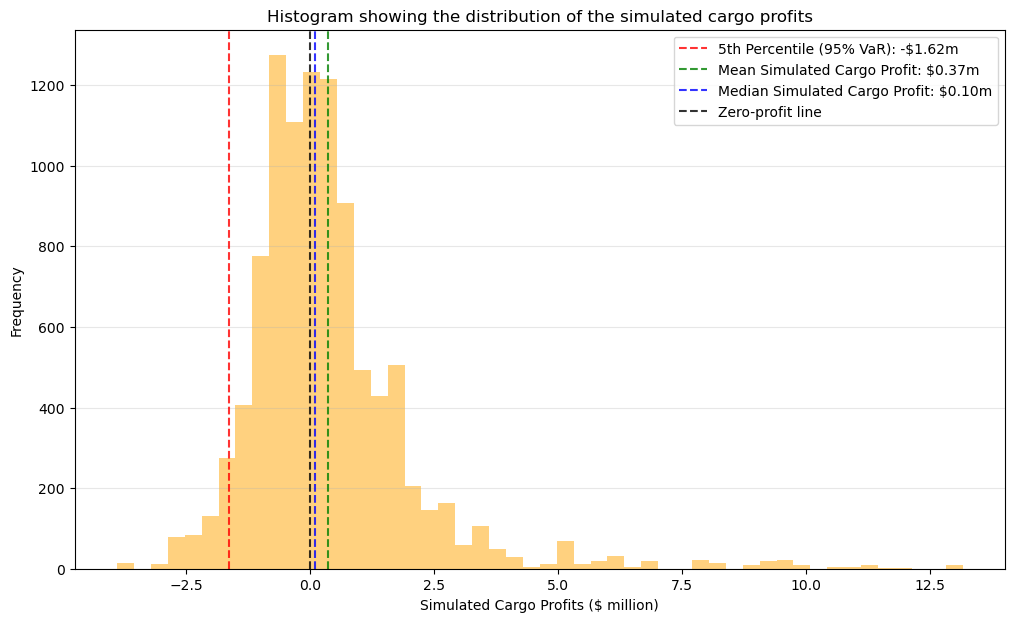

In [93]:
#Histogram illustration to visualise the Monte Carlo results 

plt.figure(figsize = (12,7))
plt.hist(simulations["Cargo Profit ($ million)"], bins = 50, alpha = 0.5, color = 'orange')
plt.xlabel("Simulated Cargo Profits ($ million)")
plt.ylabel("Frequency")
plt.title("Histogram showing the distribution of the simulated cargo profits")
plt.axvline(fifth_percentile, color = 'red', linestyle = '--', label = f"5th Percentile (95% VaR): -${abs(fifth_percentile):.2f}m", alpha = 0.8)
plt.axvline(mean_cargo_profit, color = 'green', linestyle = '--', label = f"Mean Simulated Cargo Profit: ${mean_cargo_profit:.2f}m", alpha = 0.8 )
plt.axvline(median_cargo_profit, color = 'blue', linestyle = '--', label = f"Median Simulated Cargo Profit: ${median_cargo_profit:.2f}m", alpha = 0.8)
plt.axvline(0, color = 'black', linestyle = '--', label = "Zero-profit line", alpha = 0.8)
plt.grid(axis = "y", alpha = 0.3)
plt.legend(loc = 'best')
plt.show()

## 6. Mean Reversion Analysis

A variable is mean reverting if it has the tendency to move back towards its long-run level after moving away from it.

For example, if the Brent-WTI spread data displayed mean reverting behaviour, then we would see unusually high starting spreads tend to be followed by negative spread changes, while unusually low starting spreads tend to be followed by positive spread changes.

We can plot a scatter graph of 18-Day Spread Change against Starting Spread and perform some statistical analysis to see if there is consistency with mean-reverting behaviour.

### 6.1 18 Day Spread Change vs Starting Spread

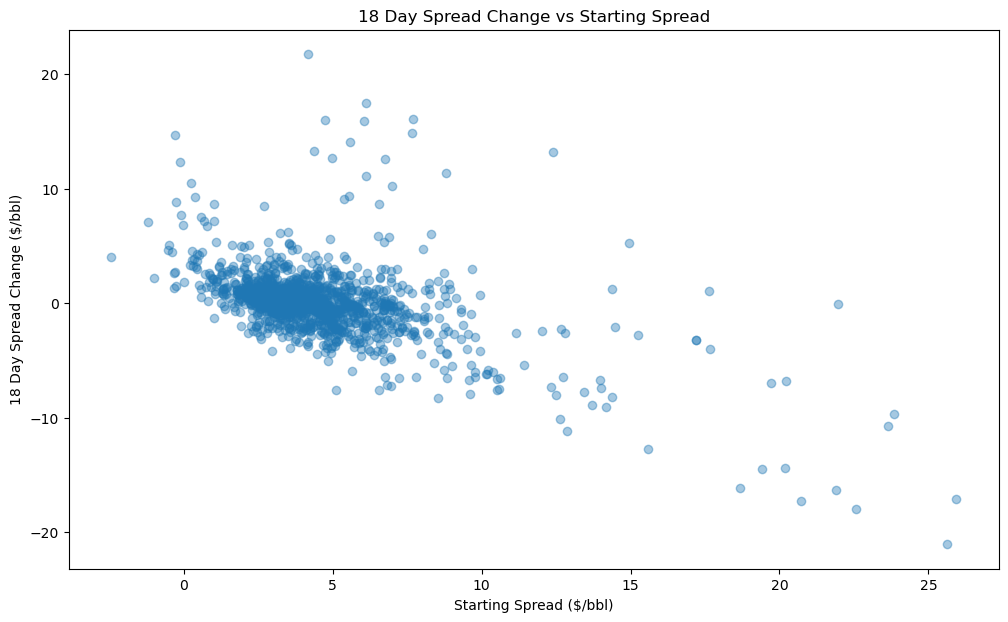

In [94]:
plt.figure(figsize = (12,7))
plt.scatter(oil["Starting Spread"], oil["18 Day Spread Change"], alpha = 0.4)
plt.xlabel("Starting Spread ($/bbl)")
plt.ylabel("18 Day Spread Change ($/bbl)")
plt.title("18 Day Spread Change vs Starting Spread")
plt.show()

The scatter plot shows a clear downward tendency, providing initial visual evidence consistent with mean-reverting behaviour.

### 6.2 Correlation Analysis

We can check the correlation between the two variables to quantify the strength and direction of the linear relationship observed in the scatter plot.

In [95]:
mean_reversion_correlation = oil[["Starting Spread", "18 Day Spread Change"]].corr()
print(mean_reversion_correlation)

                      Starting Spread  18 Day Spread Change
Starting Spread              1.000000             -0.534004
18 Day Spread Change        -0.534004              1.000000


Our result is **r = -0.534** indicating that there is moderate negative relationship between Starting Spread and the subsequent 18-Day Spread Change.

In other words, generally speaking, with a higher starting spread, we see a more negative subsequent 18-day spread change and vice versa.

This is consistent with mean-reverting behaviour.

### 6.3 Regression Analysis

We can also perform regression analysis on the data, first determining the equation of the fitted regression line.

In [96]:
regression_data = oil[["Starting Spread", "18 Day Spread Change"]].dropna()
slope, intercept = np.polyfit(regression_data["Starting Spread"], regression_data["18 Day Spread Change"], 1)

print("Slope:", slope)
print("Intercept:", intercept)

Slope: -0.5764695293495763
Intercept: 2.6608620388474686


**Equation of fitted regression line**

The equation of the fitted regression line is:

$$
y = -0.576x + 2.661
$$

For every $\$1/\text{bbl}$ increase in the starting spread, the expected subsequent 18-day spread change is approximately $\$0.58/\text{bbl}$ lower.

__Estimated equilibrium spread__

From the equation of the fitted regression line, we can set it equal to 0 to calculate the estimated equilibrium spread, S*. This is the spread value at which the subsequent 18-day spread change is zero.

Doing this we get:

S* $\approx\$ $\$4.62/\text{bbl}$

Combining the scatter plot and fitted regression line, we get:

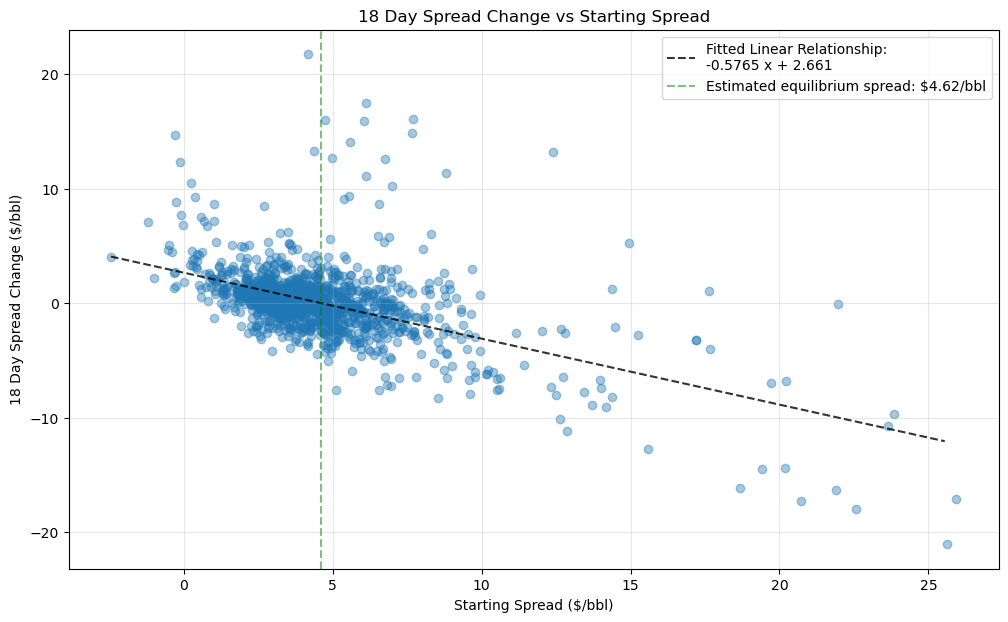

In [97]:
regression_function = np.poly1d((slope, intercept))

min_starting_spread = oil["Starting Spread"].min()
max_starting_spread = oil["Starting Spread"].max()
starting_spreads_range = np.arange(min_starting_spread, max_starting_spread, 0.5)

#Equilibrium/central spread, S0, where the regression predicts zero 18-day change
S0 = -intercept/slope

plt.figure(figsize = (12,7))
plt.scatter(oil["Starting Spread"], oil["18 Day Spread Change"], alpha = 0.4)
plt.plot(starting_spreads_range, regression_function(starting_spreads_range), linestyle = '--', color = 'black', alpha = 0.8, label = f"Fitted Linear Relationship: {regression_function}")
plt.xlabel("Starting Spread ($/bbl)")
plt.ylabel("18 Day Spread Change ($/bbl)")
plt.title("18 Day Spread Change vs Starting Spread")
plt.axvline(S0, linestyle = '--', color = 'green', alpha = 0.5, label = f"Estimated equilibrium spread: ${S0:.2f}/bbl")
plt.legend(loc = 'best')
plt.grid(True, alpha = 0.3)
plt.show()


**$R^2%$ Analysis**

$R^2$ $\approx$ 0.285

The regression has an $R^2$ value of approximately 0.285, meaning that around 28.5% of the observed variation in the 18-day spread changes can be explained with the linear relationship with the starting spread.

This is consistent with the visible scatter of the data points around the fitted regression line, indicating that a significant proportion of the data remains unexplained by the model, which could be a result of several factors such as supply/demand changes, market shocks, macro events or other variables not included in the model.

__Regression significance analysis__

To establish the significance of the regression analysis, we need to first outline our hypotheses, significance level and determine the regression p-value, comparing it to the significance level.

Null hypothesis, $H_0$: $\beta_1$ = 0

Null hypothesis says that the regression slope is zero - there is no linear relationship between starting Brent-WTI spread and the subsequent 18-day spread change.

Alternative hypothesis, $H_1$: $\beta_1$ $\neq$ 0

Alternative hypothesis says that the regression slope is not zero - there is a linear relationship between starting Brent-WTI spread and the subsequent 18-day spread change.


In [98]:
from scipy.stats import linregress
regression_results = linregress(regression_data["Starting Spread"], regression_data["18 Day Spread Change"])

print("P-value:", regression_results.pvalue)

P-value: 2.6195970068331336e-100


The regression p-value comes out to be approximately $2.61$ x $10^{-100}$; at the 5% significance level, the p-value is substantially below 0.05.

Therefore, our regression analysis is significant and we can reject the null hypothesis, supporting that there is a linear relationship between starting Brent-WTI spread and the subsequent 18-day spread change.

### 6.4 Augmented Dickey-Fuller Test

The Augmented Dickey-Fuller (ADF) test is used to assess whether the Brent-WTI spread contains a unit root or instead exhibits stationary behaviour.

This helps assess whether shocks to the spread tend to be temporary rather than permanent, which would mean the spread demonstrates stationarity and would be consistent with mean-reverting behaviour.



**ADF statistic**


In [99]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(oil["Spread"].dropna())

print("ADF Statistic:", adf_result[0])
print("P-value:", adf_result[1])

ADF Statistic: -5.146369464987155
P-value: 1.1301691277071071e-05


**ADF test significance**

Null hypothesis, $H_0$: The Brent-WTI spread contains a unit root and is non-stationary.

Alternative hypothesis, $H_1$: The Brent-WTI spread is stationary.

The ADF p-value comes out to approximately $1.13$ x $10^{-5}$ which is comfortably lower than 0.05 at the 5% significance level.

Therefore, we can reject $H_0$, supporting that the Brent-WTI spread is stationary over the sample time period.

Stationarity is consistent with mean-reverting behaviour as shocks to the spread are temporary.

**Overall Mean-Reversion Conclusion**

Taken together, the negative correlation, regression relationship and ADF result provide evidence consistent with mean-reverting behaviour in the historical Brent-WTI spread.

## 7. Freight Sensitivity 

A preliminary freight analysis was introduced in Chapter 2.4 illustrating the effect of changing the freight cost per barrel on the trade profitability, whilst keeping the capital and other costs constant.

In this chapter, we will extend that analysis by evaluating a range of freight-cost scenarios across the full historical dataset.

The break-even spread is recalculated for each freight assumption while retaining the variable financing cost associated with the daily WTI purchase price.

Alongside this, the resulting effects on the proportion of profitable trading days and average cargo profit are then assessed.

### 7.1 Freight Sensitivity Table

Freight cost scenarios ranging from $\$2.50/\text{bbl}$ to $\$4.50/\text{bbl}$ in $\$0.50/\text{bbl}$ increments were used to assess the sensitivity of trade profitability to changes in shipping costs. 

As historical freight-rate data were not available, these scenarios are treated as assumptions rather than observed market values. 

Nevertheless, the range provides a useful basis for evaluating the effect of freight costs on the break-even spread and overall trade profitability. 

To clearly display the results obtained, a freight sensitivity table was created, presenting the average break-even spread, proportion of profitable days and average cargo profit for each freight cost scenario.

In [100]:
freight_scenarios = [2.50, 3.00, 3.50, 4.00, 4.50]
freight_sensitivity_results = []

for freight in freight_scenarios:

    break_even = (oil["Capital Cost per bbl"] + freight + other_costs_per_bbl)

    profit_per_bbl = oil["Spread"] - break_even

    cargo_profit = profit_per_bbl * cargo_size / 1000000

    average_break_even = break_even.mean()
    profitable_days = (profit_per_bbl > 0).mean() * 100
    average_cargo_profit = cargo_profit.mean()

    freight_sensitivity_results.append([freight, average_break_even, profitable_days, average_cargo_profit])

freight_sensitivity_table = pd.DataFrame(
    freight_sensitivity_results,
    columns = [
        "Freight Cost ($/bbl)",
        "Average Break-even Spread ($/bbl)",
        "Percentage of Profitable Days (%)",
        "Average Cargo Profit ($ million)"
    ])

print(freight_sensitivity_table)

   Freight Cost ($/bbl)  Average Break-even Spread ($/bbl)  \
0                   2.5                           2.964477   
1                   3.0                           3.464477   
2                   3.5                           3.964477   
3                   4.0                           4.464477   
4                   4.5                           4.964477   

   Percentage of Profitable Days (%)  Average Cargo Profit ($ million)  
0                          73.811266                          0.963634  
1                          63.277249                          0.663634  
2                          52.889539                          0.363634  
3                          42.794440                          0.063634  
4                          32.479883                         -0.236366  


### 7.2 Impact on Historical Profitability

The relationship between freight cost and historical trade profitability can be illustrated graphically, by plotting the proportion of profitable days at each freight cost scenario.

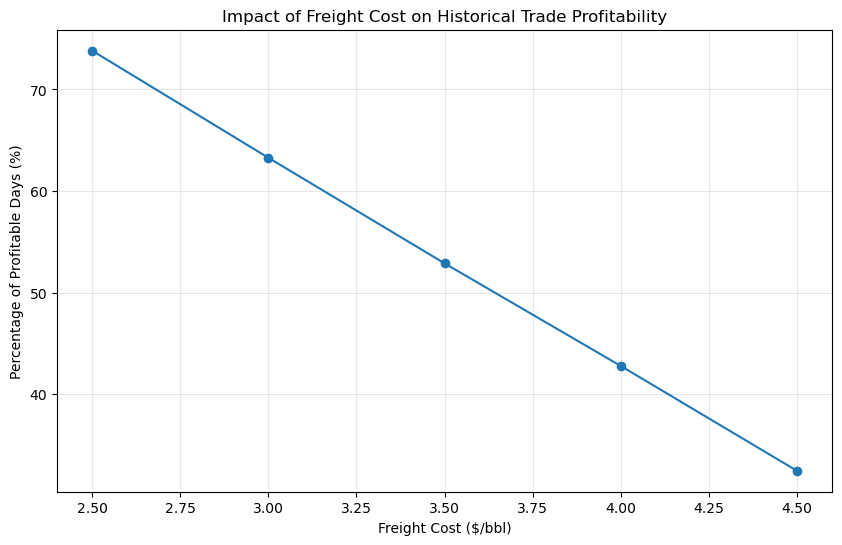

In [101]:
plt.figure(figsize=(10, 6))

plt.plot(
    freight_sensitivity_table["Freight Cost ($/bbl)"],
    freight_sensitivity_table["Percentage of Profitable Days (%)"],
    marker="o"
)

plt.xlabel("Freight Cost ($/bbl)")
plt.ylabel("Percentage of Profitable Days (%)")
plt.title("Impact of Freight Cost on Historical Trade Profitability")

plt.grid(alpha=0.3)
plt.show()

### 7.3 Zero-Profit Freight Threshold

The zero-profit freight threshold is the freight cost at which the average cargo profit is zero. 

This value was obtained by setting average cargo profit equal to zero and solving the fitted linear relationship for freight cost.


In [102]:
freight_slope, freight_intercept = np.polyfit(
     freight_sensitivity_table["Freight Cost ($/bbl)"],
     freight_sensitivity_table["Average Cargo Profit ($ million)"],
    1)

zero_profit_freight = -freight_intercept / freight_slope

print(f"The Zero-Profit Freight Threshold is: ${zero_profit_freight:.2f}/bbl")

The Zero-Profit Freight Threshold is: $4.11/bbl


### 7.4 Impact on Average Cargo Profit

A graph of average cargo profit against freight cost, showing the linear relationship between the two.

Also displayed is the zero-profit freight threshold.

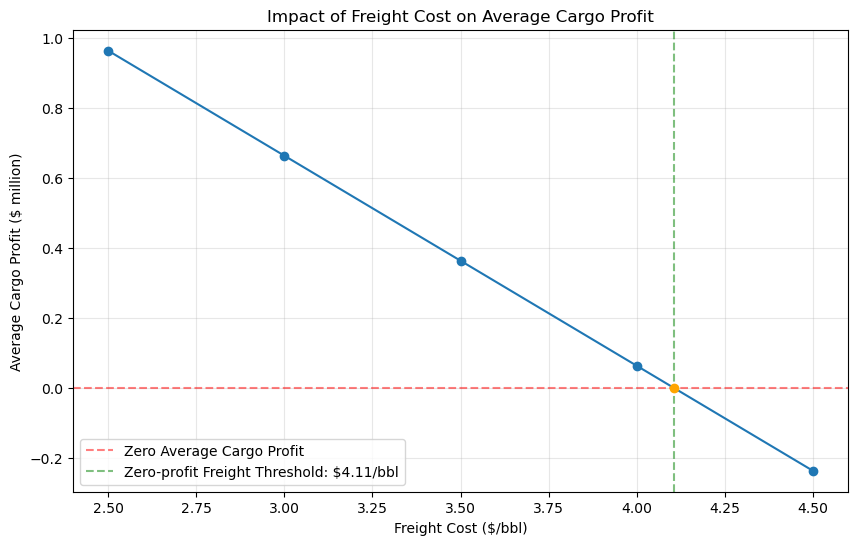

In [103]:
plt.figure(figsize = (10,6))

plt.plot(
    freight_sensitivity_table["Freight Cost ($/bbl)"],
    freight_sensitivity_table["Average Cargo Profit ($ million)"],
    marker = "o")

plt.xlabel("Freight Cost ($/bbl)")
plt.ylabel("Average Cargo Profit ($ million)")
plt.title("Impact of Freight Cost on Average Cargo Profit")
plt.axhline(0, color = 'red', linestyle = '--', alpha = 0.5, label = "Zero Average Cargo Profit")
plt.axvline(zero_profit_freight, color = 'green', linestyle = '--', alpha = 0.5, label = f"Zero-profit Freight Threshold: ${zero_profit_freight:.2f}/bbl")
plt.plot(zero_profit_freight, 0, marker = 'o', color = 'orange')
plt.legend(loc = 'best')
plt.grid(True, alpha = 0.3)
plt.show()


## 8. Limitations

This model provides a simplified representation of the economics and risk of a USGC-to-Rotterdam crude oil trade and therefore has several limitations. 

Freight costs are based on assumed scenarios rather than a historical freight-rate dataset, while the voyage period is approximated using 18 trading days. 

The bootstrap Monte Carlo simulation resamples historical spread episodes, meaning that it does not generate new market behaviour beyond what has already been observed in the dataset. 

The model also excludes several real-world factors that could affect profitability, including quality differentials, hedging costs, demurrage, operational delays and execution slippage. 

In addition, the statistical relationships identified in the historical data, including mean-reverting behaviour, may not remain stable under different future market conditions.

## 9. Conclusion

The analysis shows that the profitability of a USGC-to-Rotterdam crude oil trade depends primarily on whether the Brent-WTI spread is wide enough to exceed freight, financing and other transaction costs.

Under the baseline assumptions, the trade was profitable on slightly more than half of historical observations, while the Monte Carlo simulation also showed meaningful downside risk, including a 95% VaR of approximately $\$1.62\ million$  and a 95% CVaR of approximately $\$2.11\ million$. 

The mean-reversion analysis provided evidence that unusually wide or narrow spreads tend to move back towards more typical levels, although a large proportion of future spread movements remains unexplained by the simple regression model. 

The freight sensitivity analysis further showed that profitability is highly dependent on shipping costs, with average historical cargo profit falling to zero at a freight cost of approximately $4.11/bbl. 

Overall, the trade can be profitable, but its attractiveness is highly sensitive to market conditions and should be assessed using both expected profitability and downside risk.